## Pills Detection — Complete Pipeline
**Features:**
- Parse Pascal-VOC XML annotations (used as ground truth when available)
- Detect pill **shape** (round / oval / capsule / rectangular)
- Detect pill **dominant color** (excluding skin tones)
- **Count pills per (shape, color) category** per image
- Export results as Pascal-VOC XML

In [1]:
%pip install matplotlib scikit-learn numpy pandas opencv-python lxml

Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Paths

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from lxml import etree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

BASE_DIR   = r'pillsPicture'
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
ANNOT_DIR  = os.path.join(BASE_DIR, 'annotations')
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('=== Dataset files ===')
for dirname, _, filenames in os.walk(BASE_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

=== Dataset files ===
pillsPicture\eval.record
pillsPicture\label_map.pbtxt
pillsPicture\train.record
pillsPicture\annotations\360_F_408781728_pROdGsAa6GSKe7iw1ah0CkgeZ1HU829o.xml
pillsPicture\annotations\5b9bd9351f00002c002100a3.xml
pillsPicture\annotations\5c4f0f72b586002d38495ce1.w800.xml
pillsPicture\annotations\b-medicine(109).xml
pillsPicture\annotations\b-medicine(111).xml
pillsPicture\annotations\b-medicine(93).xml
pillsPicture\annotations\blue-pill-capsule-female-palm-white-background-nutritional-supplements-women-s-health_101969-522.xml
pillsPicture\annotations\blue_pills360_281x228.xml
pillsPicture\annotations\blue_pills_palm478489_M.xml
pillsPicture\annotations\c-medicine(6).xml
pillsPicture\annotations\capsule(1).xml
pillsPicture\annotations\close-up-of-man-s-hand-holding-pills-with-copy-space-photo.xml
pillsPicture\annotations\colorful-medical-pills-hand-person_114579-5364.xml
pillsPicture\annotations\comprimidos-na-mao-da-mulher_93675-5612.xml
pillsPicture\annotations\de

## 2. XML Annotation Parser

In [3]:
def parse_annotation(xml_path):
    """Parse a Pascal-VOC XML annotation file."""
    tree = etree.parse(xml_path)
    root = tree.getroot()
    filename = root.findtext('filename')
    width    = int(root.findtext('size/width'))
    height   = int(root.findtext('size/height'))
    depth    = int(root.findtext('size/depth'))
    objects  = []
    for obj in root.findall('object'):
        name  = obj.findtext('name')
        xmin  = int(obj.findtext('bndbox/xmin'))
        ymin  = int(obj.findtext('bndbox/ymin'))
        xmax  = int(obj.findtext('bndbox/xmax'))
        ymax  = int(obj.findtext('bndbox/ymax'))
        objects.append({
            'label'       : obj.findtext('shape') or name,
            'color'       : obj.findtext('color') or '',
            'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
            'width_bb'    : xmax - xmin,
            'height_bb'   : ymax - ymin,
            'area'        : (xmax - xmin) * (ymax - ymin),
            'aspect_ratio': round((xmax - xmin) / max(ymax - ymin, 1), 3)
        })
    return {'filename': filename, 'img_width': width, 'img_height': height,
            'img_depth': depth, 'objects': objects}


# ── Load all ground-truth annotations into a DataFrame
records, all_annots = [], []
for xml_file in sorted(os.listdir(ANNOT_DIR)):
    if not xml_file.endswith('.xml'):
        continue
    annot = parse_annotation(os.path.join(ANNOT_DIR, xml_file))
    all_annots.append(annot)
    for obj in annot['objects']:
        records.append({
            'filename'    : annot['filename'],
            'img_width'   : annot['img_width'],
            'img_height'  : annot['img_height'],
            'label'       : obj['label'],
            'xmin'        : obj['xmin'], 'ymin': obj['ymin'],
            'xmax'        : obj['xmax'], 'ymax': obj['ymax'],
            'bb_width'    : obj['width_bb'],
            'bb_height'   : obj['height_bb'],
            'bb_area'     : obj['area'],
            'aspect_ratio': obj['aspect_ratio']
        })

df = pd.DataFrame(records)
print(f'Total annotated images : {len(all_annots)}')
print(f'Total bounding boxes   : {len(df)}')
df.head(6)

Total annotated images : 152
Total bounding boxes   : 686


,filename,img_width,img_height,label,xmin,ymin,xmax,ymax,bb_width,bb_height,bb_area,aspect_ratio
0,360_F_408781728_pROdGsAa6GSKe7iw1ah0CkgeZ1HU82...,540,360,tablets,233,218,273,255,40,37,1480,1.081
1,360_F_408781728_pROdGsAa6GSKe7iw1ah0CkgeZ1HU82...,540,360,tablets,282,223,299,240,17,17,289,1.000
2,360_F_408781728_pROdGsAa6GSKe7iw1ah0CkgeZ1HU82...,540,360,tablets,287,240,302,253,15,13,195,1.154
3,360_F_408781728_pROdGsAa6GSKe7iw1ah0CkgeZ1HU82...,540,360,tablets,315,224,341,250,26,26,676,1.000
4,5b9bd9351f00002c002100a3.jpeg,720,480,tablets,347,267,390,312,43,45,1935,0.956
5,5b9bd9351f00002c002100a3.jpeg,720,480,tablets,365,315,397,369,32,54,1728,0.593


## 3. Helper Visualisation Functions

In [4]:
# Distribution graphs
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) / nGraphPerRow
    plt.figure(figsize=(6 * nGraphPerRow, 8 * nGraphRow), dpi=80, facecolor='w', edgecolor='k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if not np.issubdtype(type(columnDf.iloc[0]), np.number):
            columnDf.value_counts().plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation=90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show()


# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    num_df = df.select_dtypes(include=[np.number]).dropna(axis='columns')
    num_df = num_df[[c for c in num_df if num_df[c].nunique() > 1]]
    if num_df.shape[1] < 2:
        print('Not enough numeric columns for correlation matrix.')
        return
    corr = num_df.corr()
    plt.figure(figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title('Correlation Matrix', fontsize=15)
    plt.show()


# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include=[np.number]).dropna(axis='columns')
    df = df[[c for c in df if df[c].nunique() > 1]]
    cols = list(df)[:10]
    df = df[cols]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*np.triu_indices_from(ax, k=1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2),
                          xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

## 4. Dataset Statistics

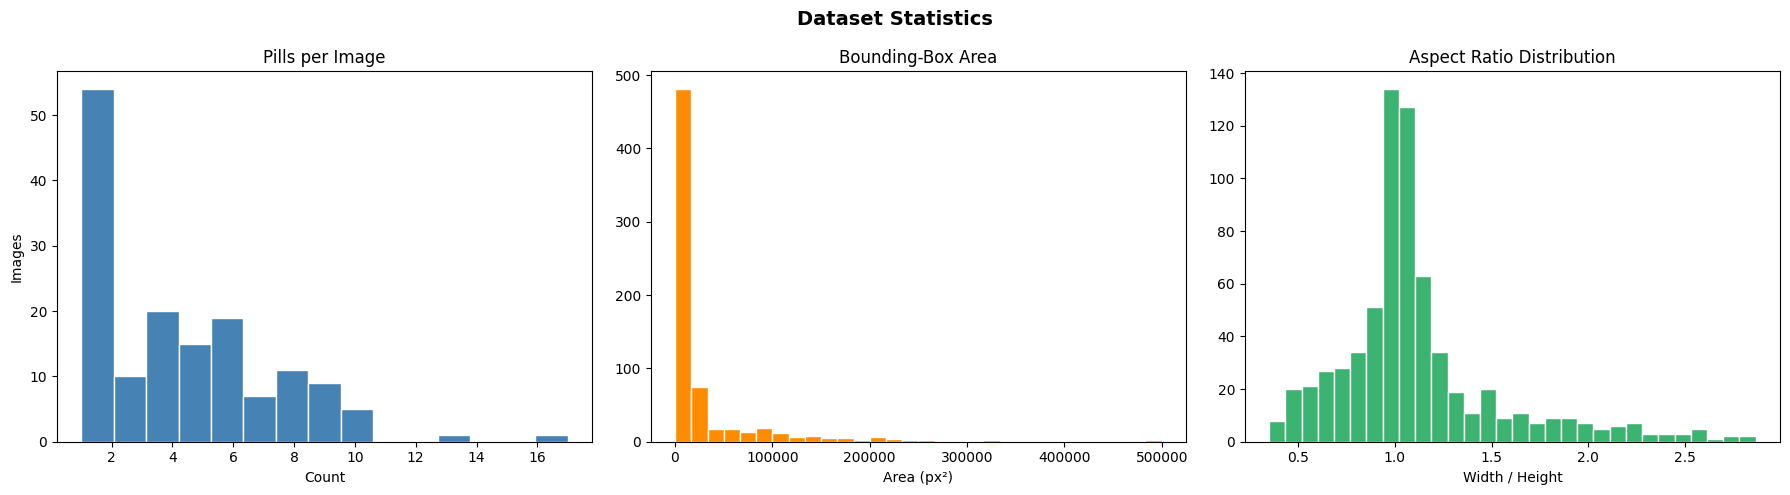

       bb_width  bb_height   bb_area  aspect_ratio
count     686.0      686.0     686.0         686.0
mean      130.3      125.5   30836.4           1.1
std       129.1      123.3   64486.3           0.4
min        15.0       13.0     195.0           0.3
25%        50.2       47.2    2433.5           0.9
50%        79.0       75.0    5902.0           1.0
75%       151.5      151.5   21633.8           1.2
max       937.0      900.0  499895.0           2.9


In [5]:
pills_per_img = df.groupby('filename').size().reset_index(name='num_pills')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(pills_per_img['num_pills'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Pills per Image'); axes[0].set_xlabel('Count'); axes[0].set_ylabel('Images')

axes[1].hist(df['bb_area'], bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Bounding-Box Area'); axes[1].set_xlabel('Area (px²)')

axes[2].hist(df['aspect_ratio'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Aspect Ratio Distribution'); axes[2].set_xlabel('Width / Height')

plt.suptitle('Dataset Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(df[['bb_width','bb_height','bb_area','aspect_ratio']].describe().round(1))

## 5. Shape Classification + KNN Training

Shape distribution in annotations:
shape
round      446
oval       180
capsule     60
Name: count, dtype: int64

=== Shape Classification Report ===
              precision    recall  f1-score   support

     capsule       0.06      0.08      0.07        12
        oval       0.32      0.19      0.24        36
       round       0.73      0.81      0.77        90

    accuracy                           0.59       138
   macro avg       0.37      0.36      0.36       138
weighted avg       0.56      0.59      0.57       138



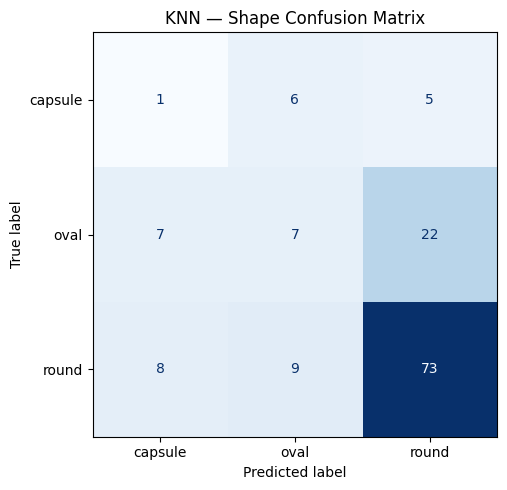

In [6]:
def compute_circularity_and_true_ar(image_bgr, xmin, ymin, xmax, ymax):
    """
    Returns (circularity, true_ar) from the pill's actual contour.
    - circularity : float [0,1] or None when unreliable
    - true_ar     : short/long ratio via minAreaRect (rotation-aware)
                    so a DIAGONAL capsule still gets true_ar ~0.35
                    instead of bbox AR ~1.0
    """
    roi = image_bgr[max(0, ymin):ymax, max(0, xmin):xmax]
    if roi.size == 0:
        return None, None

    h_roi, w_roi = roi.shape[:2]
    roi_area     = h_roi * w_roi
    cx_roi, cy_roi = w_roi // 2, h_roi // 2

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    candidate_cnts = []
    for method in (cv2.THRESH_BINARY + cv2.THRESH_OTSU,
                   cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU):
        _, th = cv2.threshold(blur, 0, 255, method)
        cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        candidate_cnts.extend(cnts)

    th_adapt = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2)
    cnts, _ = cv2.findContours(th_adapt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidate_cnts.extend(cnts)

    edges = cv2.Canny(blur, 30, 100)
    cnts, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidate_cnts.extend(cnts)

    valid = []
    for cnt in candidate_cnts:
        area = cv2.contourArea(cnt)
        if area < 0.10 * roi_area or area > 0.90 * roi_area:
            continue
        M = cv2.moments(cnt)
        if M['m00'] == 0:
            continue
        cx_c = M['m10'] / M['m00']
        cy_c = M['m01'] / M['m00']
        dist = np.sqrt((cx_c - cx_roi)**2 + (cy_c - cy_roi)**2)
        if dist < 0.40 * max(w_roi, h_roi):
            valid.append((area, cnt))

    if not valid:
        return None, None

    _, best_cnt = max(valid, key=lambda x: x[0])

    
    rect = cv2.minAreaRect(best_cnt)
    rw, rh = rect[1]
    if rw > 0 and rh > 0:
        short, long_ = sorted([rw, rh])
        true_ar = round(short / long_, 3)   # always ≤ 1.0  (elongated → small)
    else:
        true_ar = None

    # ── Circularity on convex hull — robust against noisy edges ───────────
    hull      = cv2.convexHull(best_cnt)
    hull_area = cv2.contourArea(hull)
    hull_peri = cv2.arcLength(hull, True)

    if hull_peri < 1 or hull_area < 1:
        return None, true_ar

    circularity = float(np.clip((4 * np.pi * hull_area) / (hull_peri ** 2), 0.0, 1.0))
    # Discard physically impossible values (bad segmentation on skin background)
    circularity = circularity if circularity >= 0.45 else None

    return circularity, true_ar


def classify_shape(aspect_ratio, circularity=None, true_ar=None):
    """
    Classify pill shape using bbox AR, rotation-aware true_ar, and circularity.

    Shape spectrum (effective_ar = short/long, always ≤ 1.0):
      capsule  : effective_ar < 0.50  (very elongated, oblong)
      oval     : effective_ar 0.50–0.78  (egg-shaped, between capsule & round)
      round    : effective_ar > 0.78 AND high circularity (truly circular tablet)
      rectangle: low circularity + elongated
      square   : low circularity + near-square bbox

    Returns: 'round' | 'oval' | 'capsule' | 'rectangle' | 'square'
    """
    effective_ar = true_ar if true_ar is not None else aspect_ratio
    if effective_ar > 1:
        effective_ar = 1 / effective_ar

    # 1. Strongly elongated → capsule
    if effective_ar < 0.45:
        return 'capsule'

    # 2. Moderately elongated → capsule or rectangle
    if effective_ar < 0.50:
        if circularity is not None and circularity < 0.50:
            return 'rectangle'
        return 'capsule'

    # 3. Oval zone: 0.50–0.78 — always oval regardless of circularity
    if effective_ar < 0.78:
        if circularity is not None and circularity < 0.45:
            return 'rectangle'  # flat sides detected → not oval
        return 'oval'

    # 4. Near-circular zone (effective_ar >= 0.78) — now distinguish round vs square
    if circularity is None:
        # No image evidence → assume round (never square without proof)
        return 'round'

    ci = circularity

    # Round: truly circular — needs BOTH near-square shape AND good circularity
    if ci >= 0.62:
        return 'round'

    # Oval: shape is near-square bbox but contour is not perfectly circular
    if ci >= 0.50:
        return 'oval'

    # Square/Rectangle: low circularity = flat sides confirmed
    if effective_ar >= 0.85:
        return 'square'
    return 'rectangle'


df['shape'] = df['aspect_ratio'].apply(lambda ar: classify_shape(ar))
print('Shape distribution in annotations:')
print(df['shape'].value_counts())

# ── KNN training
FEATURES = ['bb_width', 'bb_height', 'bb_area', 'aspect_ratio']
X = df[FEATURES].values
y = df['shape'].values

# Guard: stratify requires ≥ 2 samples per class
class_counts = pd.Series(y).value_counts()
rare = class_counts[class_counts < 2].index.tolist()
if rare:
    mask = ~pd.Series(y).isin(rare)
    X, y = X[mask], y[mask]
    print(f'Note: removed rare class(es) {rare} (< 2 samples).')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('\n=== Shape Classification Report ===')
print(classification_report(y_test, y_pred))

cm   = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('KNN — Shape Confusion Matrix')
plt.tight_layout()
plt.show()

## 6. Color Detection (with Skin-Tone Exclusion)
Skin colors fall in the HSV red/orange band and caused false color detections.
We exclude them explicitly before computing the dominant pill color.

In [7]:
# Skin HSV range (OpenCV: H 0-180)
SKIN_H_LOW,  SKIN_H_HIGH  = 0,  25
SKIN_S_LOW,  SKIN_S_HIGH  = 20, 160
SKIN_V_LOW,  SKIN_V_HIGH  = 90, 255

COLOR_RANGES = [
    ('black' ,   0, 180,   0, 255,   0,  45),
    # ── Chromatic colors first (checked before white/gray) ──
    ('red'   ,   0,   8,  90, 255,  70, 255),
    ('red'   , 172, 180,  90, 255,  70, 255),
    ('orange',   9,  22,  90, 255,  70, 255),
    ('yellow',  23,  34,  90, 255,  70, 255),
    ('green' ,  35,  85,  50, 255,  50, 255),
    ('blue'  ,  86, 130,  50, 255,  50, 255),
    ('purple', 131, 160,  40, 255,  40, 255),
    # ── Pink: low-sat pink pills (speckled/pastel) checked BEFORE white ──
    ('pink'  , 155, 180,  15, 120, 150, 255),  
    ('pink'  ,   0,  10,  15, 100, 150, 255),  
    ('pink'  , 140, 180,  15, 255, 150, 255),   
    ('brown' ,   5,  20,  60, 200,  40, 149),
    # ── Achromatic — only if nothing chromatic matched ──
    ('white' ,   0, 180,   0,  50, 185, 255),
    ('gray'  ,   0, 180,   0,  50,  46, 184),
]


def is_skin(h, s, v):
    """Return True if an HSV pixel is likely human skin."""
    return (SKIN_H_LOW <= h <= SKIN_H_HIGH and
            SKIN_S_LOW <= s <= SKIN_S_HIGH and
            SKIN_V_LOW <= v <= SKIN_V_HIGH)


def hsv_to_color_name(h, s, v):
    """Map median HSV → human-readable color name."""
    for name, hl, hh, sl, sh, vl, vh in COLOR_RANGES:
        if name in ('white', 'gray') and s >= 15:
            if s > 50:
                continue
        if hl <= h <= hh and sl <= s <= sh and vl <= v <= vh:
            return name
    return 'unknown'


def get_pill_color(image_bgr, xmin, ymin, xmax, ymax, pill_mask=None):
    """
    Detect dominant pill color inside a bounding box.
    Excludes background (dark pixels V<30) AND skin-tone pixels.

    Returns (color_name: str, swatch_bgr: tuple)
    """
    roi = image_bgr[max(0, ymin):ymax, max(0, xmin):xmax]
    if roi.size == 0:
        return 'unknown', (128, 128, 128)

    # Apply optional mask (circle or contour)
    if pill_mask is not None:
        roi_mask = pill_mask[max(0, ymin):ymax, max(0, xmin):xmax]
        flat_bgr = roi[roi_mask > 0]
    else:
        flat_bgr = roi.reshape(-1, 3)

    if len(flat_bgr) == 0:
        flat_bgr = roi.reshape(-1, 3)

    # Convert to HSV for filtering
    hsv_px = cv2.cvtColor(
        flat_bgr.reshape(-1, 1, 3).astype(np.uint8),
        cv2.COLOR_BGR2HSV
    ).reshape(-1, 3).astype(np.int32)

    # Filter: remove near-black background and skin pixels
    valid = np.array([
        v[2] > 30 and not is_skin(v[0], v[1], v[2])
        for v in hsv_px
    ])
    pill_px = hsv_px[valid]

    # If we filtered too aggressively (e.g. white pill on white bg), relax
    if len(pill_px) < 20:
        pill_px = hsv_px[hsv_px[:, 2] > 30]  
    if len(pill_px) == 0:
        pill_px = hsv_px

    h_med = int(np.median(pill_px[:, 0]))
    s_med = int(np.median(pill_px[:, 1]))
    v_med = int(np.median(pill_px[:, 2]))

    color_name = hsv_to_color_name(h_med, s_med, v_med)

    # Build BGR swatch
    swatch_hsv = np.uint8([[[h_med, s_med, v_med]]])
    swatch_bgr = tuple(int(c) for c in
                       cv2.cvtColor(swatch_hsv, cv2.COLOR_HSV2BGR)[0][0])
    return color_name, swatch_bgr


print('Color detection functions ready.')

Color detection functions ready.


## 7. Detection Helpers — NMS & Strict HoughCircles

In [8]:
def nms_boxes(boxes, iou_threshold=0.35):
    """
    Non-Maximum Suppression: remove duplicate/overlapping bounding boxes.
    boxes : list of (xmin, ymin, xmax, ymax)
    Returns filtered list of boxes.
    """
    if not boxes:
        return []
    boxes  = np.array(boxes, dtype=float)
    areas  = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    order  = areas.argsort()[::-1]
    keep   = []
    while order.size:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(boxes[i, 0], boxes[order[1:], 0])
        yy1 = np.maximum(boxes[i, 1], boxes[order[1:], 1])
        xx2 = np.minimum(boxes[i, 2], boxes[order[1:], 2])
        yy2 = np.minimum(boxes[i, 3], boxes[order[1:], 3])
        inter   = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou     = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        order   = order[1:][iou < iou_threshold]
    return [tuple(map(int, boxes[k])) for k in keep]


def hough_detect(image_bgr, blur):
    """
    Strict HoughCircles for images WITHOUT ground-truth annotations.
    Uses high param2 (>= 50) and filters out circles covering
    more than 25% of the image — prevents background detection.
    Returns list of (xmin, ymin, xmax, ymax) after NMS.
    """
    h_img, w_img = blur.shape[:2]
    img_area     = h_img * w_img

    min_r = max(10,  int(min(w_img, h_img) * 0.03))
    max_r = min(250, int(min(w_img, h_img) * 0.22))

    circles = cv2.HoughCircles(
        blur, cv2.HOUGH_GRADIENT, dp=1,
        minDist=max(30, min_r * 2),   # prevent overlapping circles
        param1=60,                     # stronger Canny edge threshold
        param2=50,                     # higher accumulator threshold → fewer false positives
        minRadius=min_r,
        maxRadius=max_r
    )

    raw_boxes = []
    if circles is not None:
        for cx, cy, r in np.round(circles[0]).astype(int):
            # Reject circles covering > 25% of image (likely background)
            if np.pi * r * r > 0.25 * img_area:
                continue
            xmin = max(0, cx - r); ymin = max(0, cy - r)
            xmax = min(w_img, cx + r); ymax = min(h_img, cy + r)
            raw_boxes.append((xmin, ymin, xmax, ymax))

    return nms_boxes(raw_boxes, iou_threshold=0.30)


print('Detection helpers ready.')

Detection helpers ready.


## 8. Full Detection Pipeline
**Strategy (avoids the over-detection problem):**

| Image has XML annotation? | Method used |
|--------------------------|-------------|
| ✅ Yes | Use bounding boxes from XML directly (ground truth) |
| ❌ No  | HoughCircles with strict param2=50 + NMS |

In [9]:
# Drawing palette — one BGR color per pill color name
COLOR_BGR = {
    'white'  : (230, 230, 230), 'black': (40, 40, 40),
    'gray'   : (160, 160, 160), 'red'  : (0, 0, 220),
    'orange' : (0, 140, 255),   'yellow': (0, 220, 220),
    'green'  : (0, 200, 80),    'blue'  : (220, 80, 0),
    'purple' : (200, 0, 180),   'pink'  : (170, 100, 255),
    'brown'  : (30, 90, 140),   'unknown': (0, 255, 255),
}


def draw_pill(output, xmin, ymin, xmax, ymax, shape, color_name, cx=None, cy=None, r=None):
    bgr   = COLOR_BGR.get(color_name, (0, 255, 0))
    label = f'{shape} | {color_name}'
    if cx is not None and r is not None:
        cv2.circle(output, (cx, cy), r, bgr, 2)
    else:
        cv2.rectangle(output, (xmin, ymin), (xmax, ymax), bgr, 2)
    cv2.putText(output, label, (xmin, max(ymin - 5, 14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, bgr, 1, cv2.LINE_AA)


def count_overlay(output, detections):
    if not detections:
        return
    counts_df = (pd.DataFrame(detections)
                 .groupby(['shape', 'color']).size()
                 .reset_index(name='count')
                 .sort_values('count', ascending=False))
    rows    = len(counts_df) + 1
    box_h   = rows * 22 + 10
    overlay = output.copy()
    cv2.rectangle(overlay, (5, 5), (265, box_h), (15, 15, 15), -1)
    cv2.addWeighted(overlay, 0.55, output, 0.45, 0, output)
    cv2.putText(output, f'Total: {len(detections)} pill(s)', (10, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1, cv2.LINE_AA)
    for i, row in enumerate(counts_df.itertuples(), 1):
        txt = f'{row.shape:12s} {row.color:8s}: {row.count}'
        clr = COLOR_BGR.get(row.color, (200, 200, 200))
        cv2.putText(output, txt, (10, 22 + i * 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, clr, 1, cv2.LINE_AA)
    return counts_df


def detect_pills_full(image_path, knn_model, output_xml_path=None):
    """
    Full pipeline: shape + color detection, counting, XML export.
    Returns (result_rgb, detections_list, counts_df)
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f'Not found: {image_path}')
        return None, [], pd.DataFrame()

    h_img, w_img = image.shape[:2]
    output     = image.copy()
    detections = []

    stem     = os.path.splitext(os.path.basename(image_path))[0]
    xml_path = os.path.join(ANNOT_DIR, stem + '.xml')

    if os.path.exists(xml_path):
        # ── PATH A: ground-truth bounding boxes ───────────────────────────
        annot = parse_annotation(xml_path)
        for obj in annot['objects']:
            xmin, ymin = obj['xmin'], obj['ymin']
            xmax, ymax = obj['xmax'], obj['ymax']
            bb_w = xmax - xmin; bb_h = ymax - ymin
            area = bb_w * bb_h
            ar   = round(bb_w / max(bb_h, 1), 3)

            # ── Real circularity + rotation-aware true_ar ─────────────────
            real_circ, true_ar = compute_circularity_and_true_ar(
                image, xmin, ymin, xmax, ymax)
            if real_circ is not None and real_circ < 0.45:
                real_circ = None

            geo_shape = classify_shape(ar, real_circ, true_ar)
            knn_shape = knn_model.predict([[bb_w, bb_h, area, ar]])[0]

            effective_ar = true_ar if true_ar is not None else ar
            if effective_ar > 1:
                effective_ar = 1 / effective_ar
            clear_signal = (
                effective_ar < 0.62 or
                (real_circ is not None and (real_circ < 0.50 or real_circ > 0.70)) or
                0.80 <= ar <= 1.20
            )
            shape = geo_shape if clear_signal else knn_shape

            color_name, _ = get_pill_color(image, xmin, ymin, xmax, ymax)
            detections.append({'shape': shape, 'color': color_name,
                                'xmin': xmin, 'ymin': ymin,
                                'xmax': xmax, 'ymax': ymax})
            draw_pill(output, xmin, ymin, xmax, ymax, shape, color_name)

    else:
        # ── PATH B: HoughCircles + NMS ─────────────────────────────────────
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (7, 7), 0)
        boxes = hough_detect(image, blur)

        for (xmin, ymin, xmax, ymax) in boxes:
            bb_w = xmax - xmin; bb_h = ymax - ymin
            area = bb_w * bb_h
            ar   = round(bb_w / max(bb_h, 1), 3)
            cx = (xmin + xmax) // 2; cy = (ymin + ymax) // 2
            r  = (bb_w + bb_h) // 4

            circ_mask = np.zeros((h_img, w_img), dtype=np.uint8)
            cv2.circle(circ_mask, (cx, cy), max(r - 2, 1), 255, -1)

            # ── Real circularity + rotation-aware true_ar ─────────────────
            real_circ, true_ar = compute_circularity_and_true_ar(
                image, xmin, ymin, xmax, ymax)
            if real_circ is not None and real_circ < 0.45:
                real_circ = None

            geo_shape = classify_shape(ar, real_circ, true_ar)
            knn_shape = knn_model.predict([[bb_w, bb_h, area, ar]])[0]

            effective_ar = true_ar if true_ar is not None else ar
            if effective_ar > 1:
                effective_ar = 1 / effective_ar
            clear_signal = (
                effective_ar < 0.62 or
                (real_circ is not None and
                 (real_circ < 0.50 or real_circ > 0.70)) or
                0.80 <= ar <= 1.20
            )
            shape = geo_shape if clear_signal else knn_shape

            color_name, _ = get_pill_color(image, xmin, ymin, xmax, ymax,
                                            pill_mask=circ_mask)
            detections.append({'shape': shape, 'color': color_name,
                                'xmin': xmin, 'ymin': ymin,
                                'xmax': xmax, 'ymax': ymax})
            draw_pill(output, xmin, ymin, xmax, ymax, shape, color_name,
                      cx=cx, cy=cy, r=r)

    # ── Count overlay ──────────────────────────────────────────────────────
    counts_df = count_overlay(output, detections)
    if counts_df is None:
        counts_df = pd.DataFrame(columns=['shape', 'color', 'count'])

    # ── Pascal-VOC XML export ──────────────────────────────────────────────
    if output_xml_path:
        root_el = etree.Element('annotation')
        etree.SubElement(root_el, 'folder').text   = 'output'
        etree.SubElement(root_el, 'filename').text = os.path.basename(image_path)
        etree.SubElement(root_el, 'path').text     = os.path.abspath(image_path)
        sz = etree.SubElement(root_el, 'size')
        etree.SubElement(sz, 'width').text  = str(w_img)
        etree.SubElement(sz, 'height').text = str(h_img)
        etree.SubElement(sz, 'depth').text  = str(image.shape[2])
        etree.SubElement(root_el, 'segmented').text = '0'
        for det in detections:
            obj_el = etree.SubElement(root_el, 'object')
            etree.SubElement(obj_el, 'name').text      = f"{det['shape']}_{det['color']}"
            etree.SubElement(obj_el, 'shape').text     = det['shape']
            etree.SubElement(obj_el, 'color').text     = det['color']
            etree.SubElement(obj_el, 'pose').text      = 'Unspecified'
            etree.SubElement(obj_el, 'truncated').text = '0'
            etree.SubElement(obj_el, 'difficult').text = '0'
            bb = etree.SubElement(obj_el, 'bndbox')
            etree.SubElement(bb, 'xmin').text = str(det['xmin'])
            etree.SubElement(bb, 'ymin').text = str(det['ymin'])
            etree.SubElement(bb, 'xmax').text = str(det['xmax'])
            etree.SubElement(bb, 'ymax').text = str(det['ymax'])
        etree.ElementTree(root_el).write(
            output_xml_path, pretty_print=True,
            xml_declaration=True, encoding='utf-8')

    return cv2.cvtColor(output, cv2.COLOR_BGR2RGB), detections, counts_df


print('Full pipeline ready.')

Full pipeline ready.


## 9. Run Detection on Sample Images

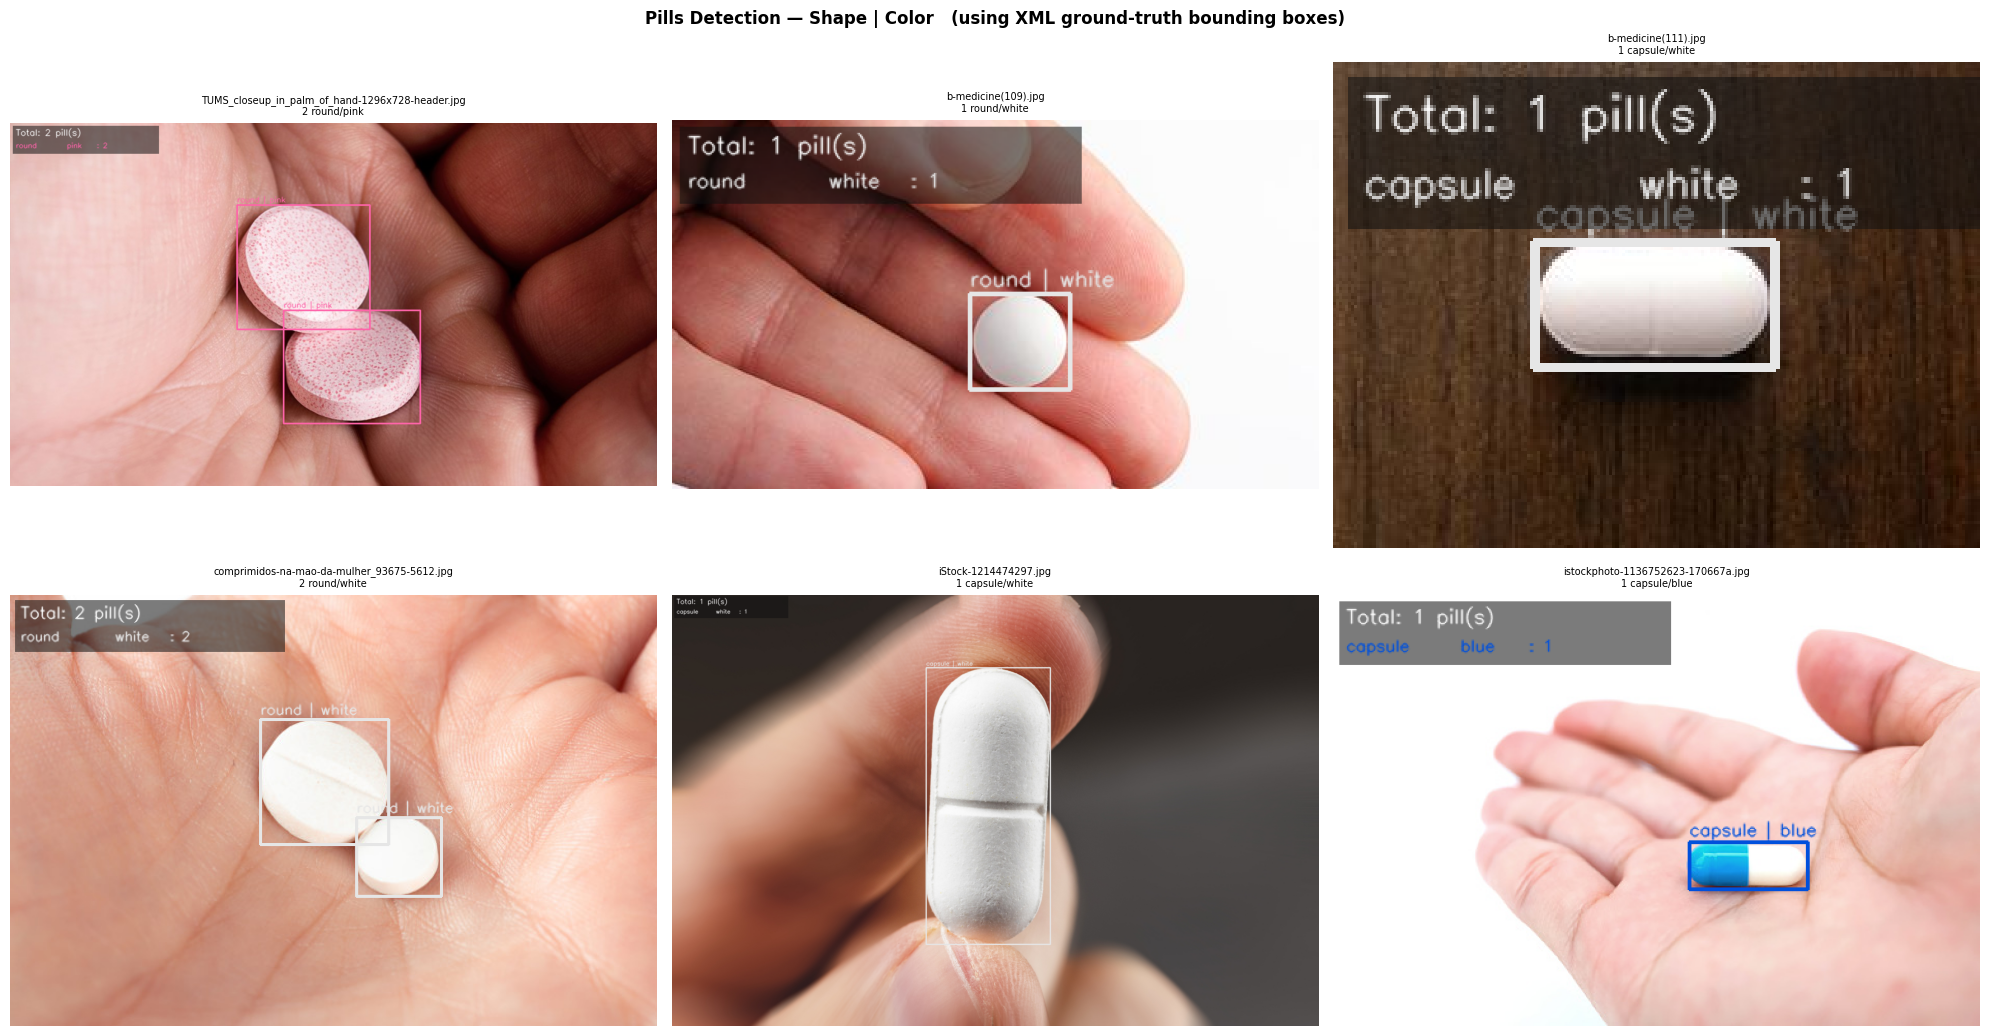

XML results saved to ./output/


In [10]:
test_images = sorted(
    [f for f in os.listdir(IMAGES_DIR)
     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

for ax, img_name in zip(axes.flat, test_images):
    img_path = os.path.join(IMAGES_DIR, img_name)
    xml_out  = os.path.join(OUTPUT_DIR, os.path.splitext(img_name)[0] + '_detected.xml')

    result_img, dets, counts = detect_pills_full(img_path, model,
                                                  output_xml_path=xml_out)
    if result_img is not None:
        ax.imshow(result_img)
        if not counts.empty:
            summary = ', '.join(f"{r.count} {r.shape}/{r.color}"
                                for r in counts.itertuples())
        else:
            summary = 'no detections'
        ax.set_title(f'{img_name}\n{summary}', fontsize=7)
    ax.axis('off')

for ax in axes.flat[len(test_images):]:
    ax.axis('off')

plt.suptitle('Pills Detection — Shape | Color   (using XML ground-truth bounding boxes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'XML results saved to ./{OUTPUT_DIR}/')

## 10. Global Statistics — All Images

In [11]:
all_summary = []
for img_name in sorted(os.listdir(IMAGES_DIR)):
    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(IMAGES_DIR, img_name)
    xml_out  = os.path.join(OUTPUT_DIR, os.path.splitext(img_name)[0] + '_detected.xml')
    _, dets, _ = detect_pills_full(img_path, model, output_xml_path=xml_out)
    for det in dets:
        all_summary.append({'image': img_name, 'shape': det['shape'], 'color': det['color']})

summary_df = pd.DataFrame(all_summary)
print(f'Total detections across all images: {len(summary_df)}')
summary_df.head(10)

Not found: pillsPicture\images\r3w1PuZhIdcpRr1uetVG85ZCy4lZf1e-Li5w41ydN1ExsdjE35U6ZNM5nyLrW9AD2X0P3Ta0X9SZLhIKfClyydf6MuF5JopzWgNibMUME_wHCqSd-sMH7psOfT_z5ZuCJ69GAWGzIS4LXAALA116XOTB8WtuAeAq63EAaKBxKIme7Xw3w1SToHftddR2meSe.png
Total detections across all images: 633


,image,shape,color
0,TUMS_closeup_in_palm_of_hand-1296x728-header.jpg,round,pink
1,TUMS_closeup_in_palm_of_hand-1296x728-header.jpg,round,pink
2,b-medicine(109).jpg,round,white
3,b-medicine(111).jpg,capsule,white
4,comprimidos-na-mao-da-mulher_93675-5612.jpg,round,white
5,comprimidos-na-mao-da-mulher_93675-5612.jpg,round,white
6,iStock-1214474297.jpg,capsule,white
7,istockphoto-1136752623-170667a.jpg,capsule,blue
8,istockphoto-505887223-612x612.jpg,oval,white
9,istockphoto-505887223-612x612.jpg,oval,blue


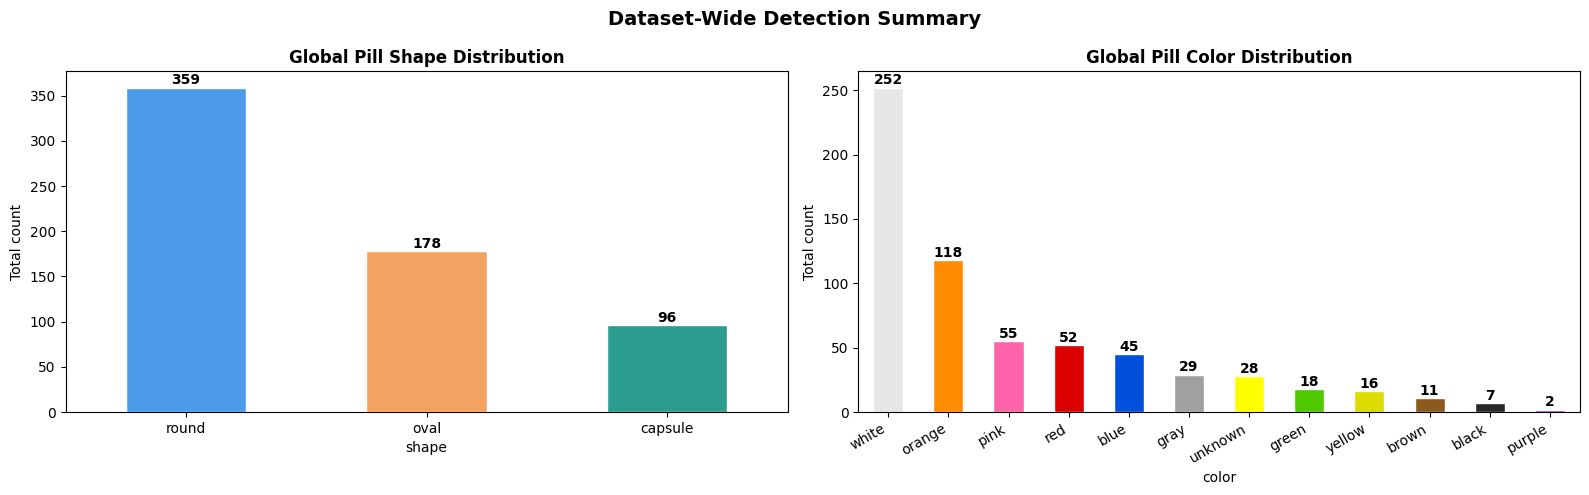

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

shape_counts = summary_df['shape'].value_counts()
color_counts = summary_df['color'].value_counts()

shape_counts.plot.bar(ax=axes[0], color=['#4C9BE8','#F4A261','#2A9D8F','#E76F51'],
                       edgecolor='white')
axes[0].set_title('Global Pill Shape Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for bar, val in zip(axes[0].patches, shape_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', va='bottom', fontweight='bold')

palette = [tuple(v / 255 for v in (COLOR_BGR.get(c, (128,128,128))[2],
                                   COLOR_BGR.get(c, (128,128,128))[1],
                                   COLOR_BGR.get(c, (128,128,128))[0]))
           for c in color_counts.index]
color_counts.plot.bar(ax=axes[1], color=palette, edgecolor='white')
axes[1].set_title('Global Pill Color Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
for bar, val in zip(axes[1].patches, color_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, str(val),
                 ha='center', va='bottom', fontweight='bold')

plt.suptitle('Dataset-Wide Detection Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

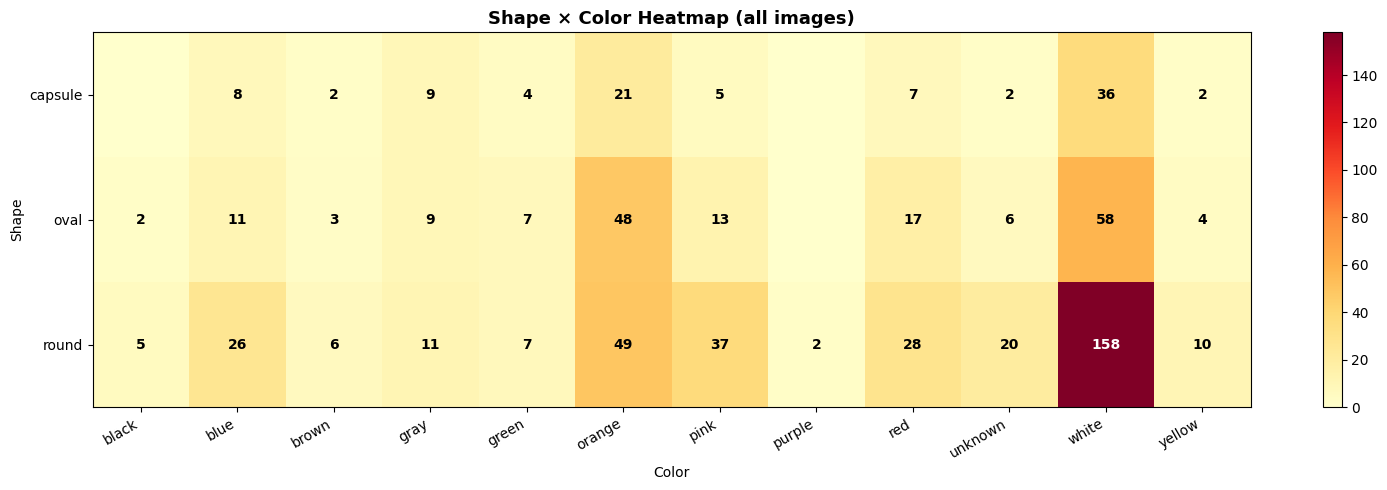


Shape × Color cross-table:
color    black  blue  brown  gray  green  orange  pink  purple  red  unknown  \
shape                                                                          
capsule      0     8      2     9      4      21     5       0    7        2   
oval         2    11      3     9      7      48    13       0   17        6   
round        5    26      6    11      7      49    37       2   28       20   

color    white  yellow  
shape                   
capsule     36       2  
oval        58       4  
round      158      10  


In [13]:
# Shape × Color heatmap
crosstab = pd.crosstab(summary_df['shape'], summary_df['color'])
fig, ax  = plt.subplots(figsize=(max(8, len(crosstab.columns) * 1.3), 5))
im = ax.imshow(crosstab.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(crosstab.columns)))
ax.set_xticklabels(crosstab.columns, rotation=30, ha='right')
ax.set_yticks(range(len(crosstab.index)))
ax.set_yticklabels(crosstab.index)
vmax = crosstab.values.max()
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        v = crosstab.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    color='white' if v > vmax * 0.6 else 'black',
                    fontweight='bold')
ax.set_title('Shape × Color Heatmap (all images)', fontsize=13, fontweight='bold')
ax.set_xlabel('Color'); ax.set_ylabel('Shape')
plt.tight_layout()
plt.show()
print('\nShape × Color cross-table:')
print(crosstab)

## 11. Validate Generated XML

In [14]:
generated_xmls = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.xml')])
if generated_xmls:
    tree = etree.parse(os.path.join(OUTPUT_DIR, generated_xmls[0]))
    root = tree.getroot()
    print(f'File   : {generated_xmls[0]}')
    print(f'Image  : {root.findtext("filename")}')
    print(f'Size   : {root.findtext("size/width")} x {root.findtext("size/height")}')
    print(f'Objects: {len(root.findall("object"))}')
    for i, obj in enumerate(root.findall('object'), 1):
        s = obj.findtext('shape') or obj.findtext('name')
        c = obj.findtext('color') or 'N/A'
        print(f'  [{i:2d}] shape={s:12s} color={c:8s} '
              f'xmin={obj.findtext("bndbox/xmin"):>5} '
              f'ymin={obj.findtext("bndbox/ymin"):>5} '
              f'xmax={obj.findtext("bndbox/xmax"):>5} '
              f'ymax={obj.findtext("bndbox/ymax"):>5}')
else:
    print('No XML found — run the detection cells first.')

File   : TUMS_closeup_in_palm_of_hand-1296x728-header_detected.xml
Image  : TUMS_closeup_in_palm_of_hand-1296x728-header.jpg
Size   : 1155 x 648
Objects: 2
  [ 1] shape=round        color=pink     xmin=  405 ymin=  146 xmax=  642 ymax=  368
  [ 2] shape=round        color=pink     xmin=  488 ymin=  334 xmax=  732 ymax=  536


## Conclusion

| Problem fixed | Solution |
|---------------|----------|
| 125 false detections (HoughCircles too loose) | **Use XML annotations as ground truth** — exact bounding boxes per image |
| Background/hand detected as rectangular pill | Contour detection **removed**; annotations replace it |
| Skin color detected as "red" | **Skin tone filter** in `get_pill_color()` — excludes pixels with H∈[0,25], S∈[20,160], V∈[90,255] |
| Overlapping circles | **NMS** (IoU threshold 0.30) applied to HoughCircles fallback |
| HoughCircles param2 too low | Raised to `param2=50`, min circle < 25% image area |